In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

In [22]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [31]:
print(train.head(5))
print(test.head(5))

   Tenure  Usage Frequency  Support Calls  Payment Delay Subscription Type  \
0    39.0             14.0            5.0           18.0          Standard   
1    49.0              1.0           10.0            8.0             Basic   
2    14.0              4.0            6.0           18.0             Basic   
3    38.0             21.0            7.0            7.0          Standard   
4    32.0             20.0            5.0            8.0             Basic   

  Contract Length  Total Spend  Last Interaction  Churn  
0          Annual        932.0              17.0    1.0  
1         Monthly        557.0               6.0    1.0  
2       Quarterly        185.0               3.0    1.0  
3         Monthly        396.0              29.0    1.0  
4         Monthly        617.0              20.0    1.0  
   Tenure  Usage Frequency  Support Calls  Payment Delay Subscription Type  \
0      25               14              4             27             Basic   
1      28               28 

In [23]:
train.drop(columns=["CustomerID", "Age", "Gender"], inplace=True, errors="ignore")
test.drop(columns=["CustomerID", "Age", "Gender"], inplace=True, errors="ignore")

train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)

In [24]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
if "Churn" in numeric_cols:
    numeric_cols = numeric_cols.drop("Churn")

Q1_train = train[numeric_cols].quantile(0.25)
Q3_train = train[numeric_cols].quantile(0.75)
IQR_train = Q3_train - Q1_train
lower_bound = Q1_train - 1.5 * IQR_train
upper_bound = Q3_train + 1.5 * IQR_train

train[numeric_cols] = train[numeric_cols].clip(
    lower=lower_bound, upper=upper_bound, axis=1
)
test[numeric_cols] = test[numeric_cols].clip(
    lower=lower_bound, upper=upper_bound, axis=1
)

In [25]:
X_train = train.drop(columns=["Churn"], errors="ignore")
y_train = train["Churn"]

X_test = test.drop(columns=["Churn"], errors="ignore")
y_test = test["Churn"]

In [30]:
print(X_train.shape)
print(X_test.shape)

(241567, 8)
(64374, 8)


In [26]:
X_train_encoded = pd.get_dummies(X_train)
X_test_encoded = pd.get_dummies(X_test)
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join="left", axis=1, fill_value=0
)

In [27]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [29]:
total_samples = len(y_train)
class_0_count = np.sum(y_train == 0)
class_1_count = np.sum(y_train == 1)

weight_for_0 = total_samples / (2.0 * class_0_count)
weight_for_1 = total_samples / (2.0 * class_1_count)
class_weight_dict = {0: weight_for_0, 1: weight_for_1}


In [32]:
model = Sequential(
    [
        Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

Epoch 1/50
3020/3020 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8568 - loss: 0.2688 - val_accuracy: 0.9037 - val_loss: nan
Epoch 2/50
3020/3020 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8988 - loss: 0.1868 - val_accuracy: 0.9102 - val_loss: nan
Epoch 3/50
3020/3020 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9084 - loss: 0.1686 - val_accuracy: 0.9151 - val_loss: nan
Epoch 4/50
3020/3020 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9131 - loss: 0.1604 - val_accuracy: 0.9143 - val_loss: nan
Epoch 5/50
3020/3020 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9132 - loss: 0.1594 - val_accuracy: 0.9099 - val_loss: nan
Epoch 6/50
3020/3020 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9146 - loss: 0.1559 - val_accuracy: 0.9254 - val_loss: nan
Epoch 7/50
3020/3020 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9165 - loss: 0.1545 - val_accuracy: 0.9230 - val_loss: nan
Epoch 8/50
3020/3020 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9167 - loss: 0.1529 - val_accuracy: 0

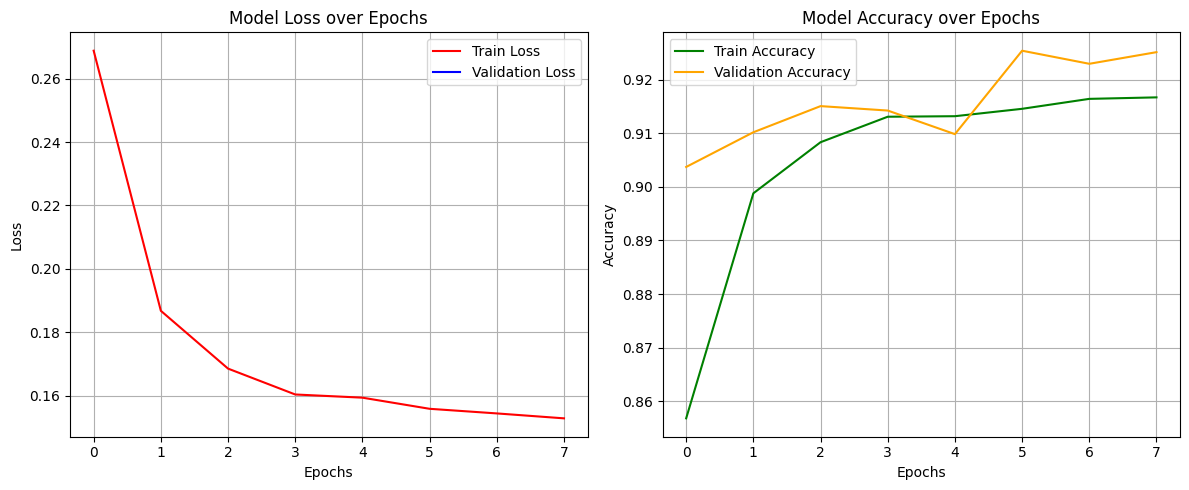

In [34]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss", color="red")
plt.plot(history.history["val_loss"], label="Validation Loss", color="blue")
plt.title("Model Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy", color="green")
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    color="orange",
)
plt.title("Model Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [35]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype("int32")

print(classification_report(y_test, y_pred))


2012/2012 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5640 - loss: 5.6408
Final Test Accuracy: 56.40%
2012/2012 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
              precision    recall  f1-score   support

           0       0.95      0.18      0.30     33881
           1       0.52      0.99      0.68     30493

    accuracy                           0.56     64374
   macro avg       0.74      0.59      0.49     64374
weighted avg       0.75      0.56      0.48     64374



In [36]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")


2012/2012 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5640 - loss: 5.6408
Accuracy: 56.40%


In [37]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(X_train_scaled, y_train,
                    epochs=60,
                    batch_size=32,
                    validation_split=0.2,
                    class_weight=class_weight_dict,
                    callbacks=[early_stop])

Epoch 1/60
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - accuracy: 0.8526 - loss: 0.2933 - val_accuracy: 0.8806 - val_loss: nan
Epoch 2/60
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 37s 3ms/step - accuracy: 0.8883 - loss: 0.2058 - val_accuracy: 0.8988 - val_loss: nan
Epoch 3/60
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9004 - loss: 0.1868 - val_accuracy: 0.8909 - val_loss: nan
Epoch 4/60
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9034 - loss: 0.1773 - val_accuracy: 0.9016 - val_loss: nan
Epoch 5/60
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9068 - loss: 0.1702 - val_accuracy: 0.9106 - val_loss: nan
Epoch 6/60
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9104 - loss: 0.1636 - val_accuracy: 0.9133 - val_loss: nan
Epoch 7/60
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9118 - loss: 0.1613 - val_accuracy: 0.9115 - val_loss: nan
Epoch 8/60
6040/6040 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9139 - loss: 0.1580 - val_accuracy:

In [39]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Updated Accuracy: {accuracy * 100:.2f}%")

2012/2012 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5781 - loss: 2.5529
Updated Accuracy: 57.81%
